<a href="https://colab.research.google.com/github/financieras/articulos/blob/main/Gradient_Descent_for_Linear_Regression_Part_1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Gradient Descent for Linear Regression. Part 1/2**
#### **Understanding the Algorithm and Basic Implementation**

<a href="https://github.com/magnitopic" target="_blank"><img src="https://img.shields.io/badge/GitHub-100000?style=flat&logo=github&logoColor=white" alt="GitHub" style="display: inline-block; vertical-align: middle; margin-right: 10px;"/></a><a href="https://www.kaggle.com/magnitopic" target="_blank"><img src="https://img.shields.io/badge/Kaggle-20BEFF?style=flat&logo=kaggle&logoColor=white" alt="Kaggle" style="display: inline-block; vertical-align: middle; margin-right: 10px;"/></a><a href="https://www.linkedin.com/in/magnitopic" target="_blank"><img src="https://img.shields.io/badge/LinkedIn-0A66C2?style=flat&logo=linkedin&logoColor=white" alt="LinkedIn" style="display: inline-block; vertical-align: middle; margin-right: 10px;"/></a>

> **Esta es la Parte 1 de 2 en nuestra serie sobre Gradient Descent.**
> Aquí aprenderás la intuición, las matemáticas esenciales y la implementación básica del algoritmo. En la Parte 2 abordaremos los hiperparámetros, el escalado de características y las implementaciones profesionales.

El Descenso del Gradiente es el motor de optimización detrás de prácticamente todo el Machine Learning moderno. En este artículo, aprenderás cómo funciona este algoritmo aplicándolo a la Regresión Lineal, combinando teoría accesible con código práctico para que entiendas **por qué funciona** y **cómo implementarlo** paso a paso.

Al final de este artículo, habrás construido tu propio algoritmo de Gradient Descent desde cero y entenderás la base sobre la que se construyen las redes neuronales.

---

## **1. Introducción: ¿Qué problema queremos resolver?**

En el corazón del Machine Learning y la Ciencia de Datos se encuentra una tarea fundamental: la **predicción**. Queremos encontrar los mejores parámetros del modelo para hacer estimaciones sobre datos que no hemos visto.

Empecemos con un ejemplo clásico y concreto: **predecir el precio de una vivienda basándonos en su tamaño.**

### El problema de predicción

Imagina que tenemos un conjunto de datos de casas. Para cada casa, conocemos su tamaño en metros cuadrados (nuestra variable $x$) y el precio final por el que se vendió (nuestra variable $y$). Si visualizamos estos datos en un gráfico, probablemente veremos una "nube de puntos" que tiende a ir hacia arriba: en general, a más metros cuadrados, mayor es el precio.

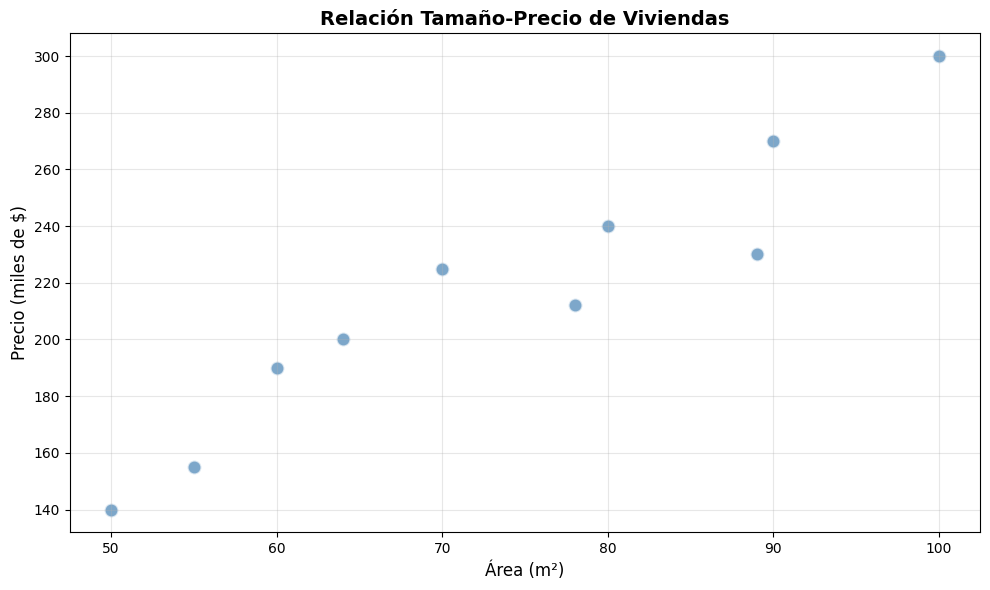

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Datos de ejemplo: tamaño de viviendas vs precio
area = np.array([50, 55, 60, 64, 70, 78, 80, 89, 90, 100])
precio = np.array([140000, 155000, 190000, 200000, 225000,
                  212000, 240000, 230000, 270000, 300000])

plt.figure(figsize=(10, 6))
plt.scatter(area, precio/1000, alpha=0.7, s=100, color='steelblue', edgecolors='white', linewidth=1.5)
plt.xlabel('Área (m²)', fontsize=12)
plt.ylabel('Precio (miles de $)', fontsize=12)
plt.title('Relación Tamaño-Precio de Viviendas', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Nuestro objetivo es trazar **una línea recta** que represente de la mejor forma posible la tendencia de esos puntos. Esta línea será nuestro "modelo" de Regresión Lineal. ¿Por qué? Porque una vez que tengamos esa línea, si alguien nos da un nuevo tamaño ($x$) de una casa que no estaba en nuestros datos, podremos "consultar" la línea para estimar su precio ($y$).

### La ecuación de nuestro modelo

Como recordarás de tus clases de matemáticas, la ecuación de una línea recta es $y = b + mx$. En Machine Learning, usamos una notación ligeramente diferente pero que significa exactamente lo mismo:

$$\hat{y} = w_0 + w_1 x$$

Vamos a analizar estos términos, ya que los usaremos durante todo el notebook:

* **$x$**: Es nuestra variable de entrada (el *feature*), en este caso, el tamaño de la casa.
* **$\hat{y}$** (se pronuncia "y-sombrero" o "y-gorro"): Es la **predicción** de nuestro modelo (el precio estimado). La distinguimos de la $y$ real (el precio de venta verdadero).
* **$w_0$**: Es el **sesgo** (del inglés *bias* o *intercept*). Es la ordenada en el origen. Representa el precio base que tendría nuestra predicción si $x$ fuera 0.
* **$w_1$**: Es el **peso** (del inglés *weight*). Es equivalente a la pendiente. Nos dice cuánto cambia $\hat{y}$ (precio) por cada unidad que aumenta $x$ (metro cuadrado).

**Nuestro objetivo:** Encontrar los valores de $w_0$ y $w_1$ que nos den la recta que mejor se ajuste a la nube de puntos.

### La pregunta fundamental: ¿Cómo encontramos los mejores parámetros?

De todas las rectas posibles (infinitas combinaciones de $w_0$ y $w_1$), ¿cómo encontramos la que **"mejor se ajusta"** a los datos? ¿Qué significa "la mejor"?

**Hay dos enfoques principales para resolver este problema:**

#### 1. **La Solución Cerrada (Normal Equation)**
Existe una fórmula matemática directa que calcula los parámetros óptimos en un solo paso:

$$\mathbf{w} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

Esta fórmula es exacta, rápida para datasets pequeños, y la aprendiste en detalle en nuestro artículo anterior sobre [Linear Regression from Scratch - Part 1](https://www.kaggle.com/code/magnitopic/linear-regression-from-scratch-in-python-part-1-2).

**Ventajas:**
- Solución exacta en una sola operación
- No requiere ajustar hiperparámetros
- Perfecta para datasets pequeños y medianos

**Limitaciones:**
- Requiere invertir una matriz, operación de complejidad $O(n^3)$
- Computacionalmente prohibitiva para datasets con millones de filas o miles de características
- Requiere cargar todos los datos en memoria
- No funciona si la matriz $\mathbf{X}^T \mathbf{X}$ es singular (no invertible)

#### 2. **El Descenso del Gradiente (Gradient Descent)**
Un algoritmo iterativo que "busca" los mejores parámetros mediante pasos sucesivos, mejorando gradualmente la solución.

**Ventajas:**
- Escala a datasets de cualquier tamaño (millones de filas, miles de características)
- Funciona con datos que no caben en memoria (procesamiento por lotes)
- Es la base de prácticamente todo el Deep Learning
- Permite actualización continua del modelo (online learning)
- Funciona para problemas no lineales y redes neuronales

**¿Cuándo necesitamos Gradient Descent?**

| Situación | Solución Cerrada | Gradient Descent |
|:----------|:-----------------|:-----------------|
| < 10,000 filas, < 100 características | ↑↑ Óptimo | ~ Funciona pero innecesario |
| 10,000 - 100,000 filas | ↑ Funciona | ↑ Buena opción |
| > 100,000 filas o > 1,000 características | ↓ Muy lento/inestable | ↑↑ **Necesario** |
| Datos que no caben en RAM | ✗ Imposible | ↑↑ **Única opción** |
| Redes Neuronales | ✗ No aplicable | ↑↑ **Única opción** |
| Necesitas online learning | ✗ No aplicable | ↑↑ **Única opción** |

### ¿Por qué aprender Gradient Descent si existe la solución cerrada?

Esta es una pregunta legítima. La respuesta tiene tres partes:

**1. Escalabilidad real:** Los problemas del mundo real suelen tener cientos de miles o millones de observaciones. En estos casos, la solución cerrada simplemente no es viable.

**2. Fundamento del Deep Learning:** Cada red neuronal que existe (desde modelos de visión por computadora hasta GPT) utiliza alguna variante del Gradient Descent. No puedes entender Deep Learning sin entender Gradient Descent.

**3. Generalidad:** Gradient Descent funciona para optimizar prácticamente cualquier función diferenciable. La solución cerrada solo existe para unos pocos problemas específicos (como la regresión lineal con MSE).

### ¿Qué aprenderás en este notebook?

Al completar este artículo, serás capaz de:

- Entender la **intuición geométrica** del Gradient Descent (sin matemáticas complejas)
- Comprender las **matemáticas esenciales**: qué es el gradiente y por qué "descender" funciona
- **Implementar el algoritmo desde cero** en Python con NumPy
- **Visualizar el proceso de optimización** y entender qué está pasando internamente
- Reconocer cuándo usar Gradient Descent vs la solución cerrada

En la **Parte 2**, llevaremos este conocimiento al siguiente nivel: dominarás los hiperparámetros críticos (learning rate), entenderás por qué el escalado de características es esencial, compararás tu implementación con scikit-learn, y extenderás el algoritmo a múltiples variables.

Pero primero, necesitamos responder una pregunta fundamental: ¿cómo medimos qué tan "buena" o "mala" es una recta? Para eso, necesitamos una **Función de Costes**.

---

## **2. Midiendo el Error: La Función de Costes**

En la sección anterior, nos quedamos con una pregunta clave: ¿cómo definimos la "mejor" línea?

Intuitivamente, la mejor línea será aquella que esté **lo más cerca posible de todos los puntos de datos** al mismo tiempo. Necesitamos una forma de cuantificar esta "cercanía" total. Esta medida es lo que llamamos la **Función de Costes** (o *Cost Function*).

### El Residuo: El Error de un Solo Punto

Primero, veamos el error para un solo punto. Digamos que tenemos una casa (nuestro punto $i$-ésimo) que mide $x_i$ metros cuadrados y se vendió por un precio real $y_i$.

Si nuestra línea (definida por $w_0$ y $w_1$) predice un precio $\hat{y}_i$ para esa casa, el error para *ese punto* es simplemente la diferencia vertical entre el valor real y el valor predicho.

$$\text{Error}_i = e_i = y_i - \hat{y}_i$$

A esta diferencia la llamamos **"residuo"**.

* Si el punto real está **por encima** de la línea ($y_i > \hat{y}_i$), el residuo $e_i$ es positivo.
* Si el punto real está **por debajo** de la línea ($y_i < \hat{y}_i$), el residuo $e_i$ es negativo.

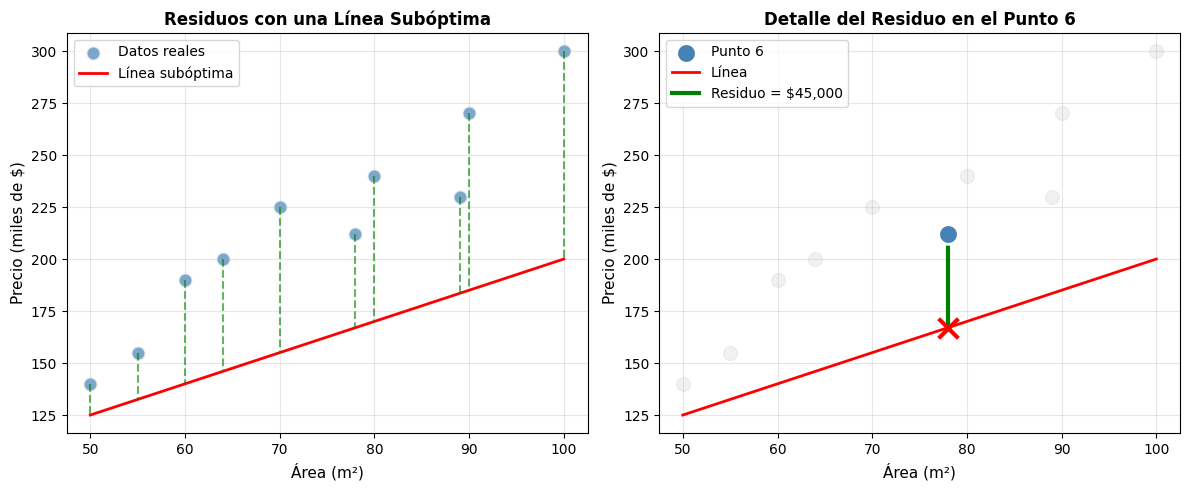

Para el punto 6:
  Área: 78 m²
  Precio real (y): $212,000
  Precio predicho (ŷ): $167,000
  Residuo (e = y - ŷ): $45,000


In [2]:
# Visualización de residuos con una línea arbitraria
plt.figure(figsize=(12, 5))

# Subplot 1: Línea con pendiente incorrecta (demasiado baja)
plt.subplot(1, 2, 1)
w0_bad, w1_bad = 50000, 1500  # Parámetros subóptimos
y_pred_bad = w0_bad + w1_bad * area

plt.scatter(area, precio/1000, alpha=0.7, s=100, color='steelblue',
            edgecolors='white', linewidth=1.5, label='Datos reales')
plt.plot(area, y_pred_bad/1000, 'r-', linewidth=2, label='Línea subóptima')

# Dibujar residuos
for i in range(len(area)):
    plt.plot([area[i], area[i]], [precio[i]/1000, y_pred_bad[i]/1000],
             'g--', alpha=0.6, linewidth=1.5)

plt.xlabel('Área (m²)', fontsize=11)
plt.ylabel('Precio (miles de $)', fontsize=11)
plt.title('Residuos con una Línea Subóptima', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Destacar un residuo específico
plt.subplot(1, 2, 2)
idx = 5  # Sexto punto
xi, yi = area[idx], precio[idx]
yi_pred = w0_bad + w1_bad * xi
residuo = yi - yi_pred

plt.scatter(area, precio/1000, alpha=0.3, s=100, color='lightgray')
plt.scatter(xi, yi/1000, s=200, color='steelblue', edgecolors='white',
            linewidth=2, label=f'Punto {idx+1}', zorder=5)
plt.plot(area, y_pred_bad/1000, 'r-', linewidth=2, label='Línea')
plt.plot([xi, xi], [yi/1000, yi_pred/1000], 'g-', linewidth=3,
         label=f'Residuo = ${residuo:,.0f}')
plt.scatter(xi, yi_pred/1000, s=200, color='red', marker='x', linewidth=3, zorder=5)

plt.xlabel('Área (m²)', fontsize=11)
plt.ylabel('Precio (miles de $)', fontsize=11)
plt.title(f'Detalle del Residuo en el Punto {idx+1}', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Para el punto {idx+1}:")
print(f"  Área: {xi} m²")
print(f"  Precio real (y): ${yi:,.0f}")
print(f"  Precio predicho (ŷ): ${yi_pred:,.0f}")
print(f"  Residuo (e = y - ŷ): ${residuo:,.0f}")

### Agregando el Error: El Error Cuadrático Medio (MSE)

Ahora, ¿cómo combinamos los residuos de *todos* nuestros puntos ($m$ puntos en total) en una sola métrica?

El primer impulso sería simplemente sumarlos. Pero esto es una **mala idea**: un residuo de +\\$1,000 y otro de -\\$1,000 se cancelarían mutuamente, haciendo parecer que nuestro modelo no tiene error, ¡cuando en realidad está fallando estrepitosamente en ambos puntos!

Para solucionar esto, hacemos dos cosas:

**1. Elevamos cada residuo al cuadrado:** $e_i^2 = (y_i - \hat{y}_i)^2$

Esto tiene dos ventajas clave:
* **Convierte todos los errores en números positivos** (ej. $(1000)^2 = 10^6$ y $(-1000)^2 = 10^6$). ¡Se acabaron las cancelaciones!
* **Penaliza los errores grandes mucho más** que los pequeños. Un error de \\$1,000 se convierte en 1,000,000, pero un error de \\$10 solo se convierte en 100. Esto fuerza al modelo a evitar predicciones muy alejadas de la realidad.

**2. Calculamos la media:** Sumamos todos estos errores al cuadrado y los dividimos por el número de puntos ($m$). Esto nos da el **Error Cuadrático Medio** (o *Mean Squared Error*, MSE).

Esta métrica es nuestra **Función de Costes**, que comúnmente se denota como $J$:

$$J(w_0, w_1) = \frac{1}{m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2$$

Si sustituimos $\hat{y}_i$ por la ecuación de nuestra línea, $(\hat{y}_i = w_0 + w_1 x_i)$, obtenemos la fórmula completa:

$$J(w_0, w_1) = \frac{1}{m} \sum_{i=1}^{m} (y_i - (w_0 + w_1 x_i))^2$$

> **Nota técnica:** En muchos libros verás esta fórmula con un $\frac{1}{2m}$ en lugar de $\frac{1}{m}$ (es decir, $J = \frac{1}{2m} \sum...$). Este $\frac{1}{2}$ se añade por pura conveniencia matemática: al derivar $(y - \hat{y})^2$ obtenemos $2(y - \hat{y})$, y el factor $\frac{1}{2}$ cancela ese 2, simplificando las ecuaciones del gradiente. **Esto no cambia dónde está el mínimo de la función**, solo hace los cálculos más limpios. En este artículo usaremos $\frac{1}{m}$ para mantener la interpretación directa de $J$ como "promedio".

In [3]:
# Función para calcular el MSE
def calcular_mse(w0, w1, x, y):
    """Calcula el Error Cuadrático Medio"""
    m = len(y)
    y_pred = w0 + w1 * x
    mse = (1/m) * np.sum((y - y_pred)**2)
    return mse

# Calculamos el MSE para nuestra línea subóptima
mse_bad = calcular_mse(w0_bad, w1_bad, area, precio)

print(f"Parámetros de la línea subóptima:")
print(f"  w₀ = ${w0_bad:,.0f}")
print(f"  w₁ = ${w1_bad:,.0f}/m²")
print(f"\nError Cuadrático Medio (MSE): {mse_bad:,.0f}")
print(f"RMSE (raíz del MSE): ${np.sqrt(mse_bad):,.0f}")
print(f"\nInterpretación: En promedio, nuestras predicciones se desvían")
print(f"aproximadamente ${np.sqrt(mse_bad):,.0f} del precio real.")

Parámetros de la línea subóptima:
  w₀ = $50,000
  w₁ = $1,500/m²

Error Cuadrático Medio (MSE): 3,735,950,000
RMSE (raíz del MSE): $61,122

Interpretación: En promedio, nuestras predicciones se desvían
aproximadamente $61,122 del precio real.


### Nuestro Nuevo Objetivo: Minimizar la Función de Costes

¡Este es el punto clave! Fíjate en $J(w_0, w_1)$. Nuestros datos ($x$ e $y$) son fijos. Por lo tanto, el coste $J$ **no es una función de $x$**, sino una **función de nuestros parámetros** $w_0$ y $w_1$.

* Diferentes valores de $w_0$ y $w_1$ (diferentes líneas) nos darán un coste $J$ diferente.
* Una línea mala tendrá un coste $J$ muy alto.
* Una línea buena tendrá un coste $J$ muy bajo.
* **La línea perfecta** minimizará $J$.

Si imaginamos todos los posibles valores de $w_0$ y $w_1$ y el coste $J$ que producen, obtendríamos una **superficie en 3D con forma de "cuenco" o valle**.

### Visualización: La Superficie de Costes en 3D

Veamos cómo se ve esta superficie de error para nuestro problema:

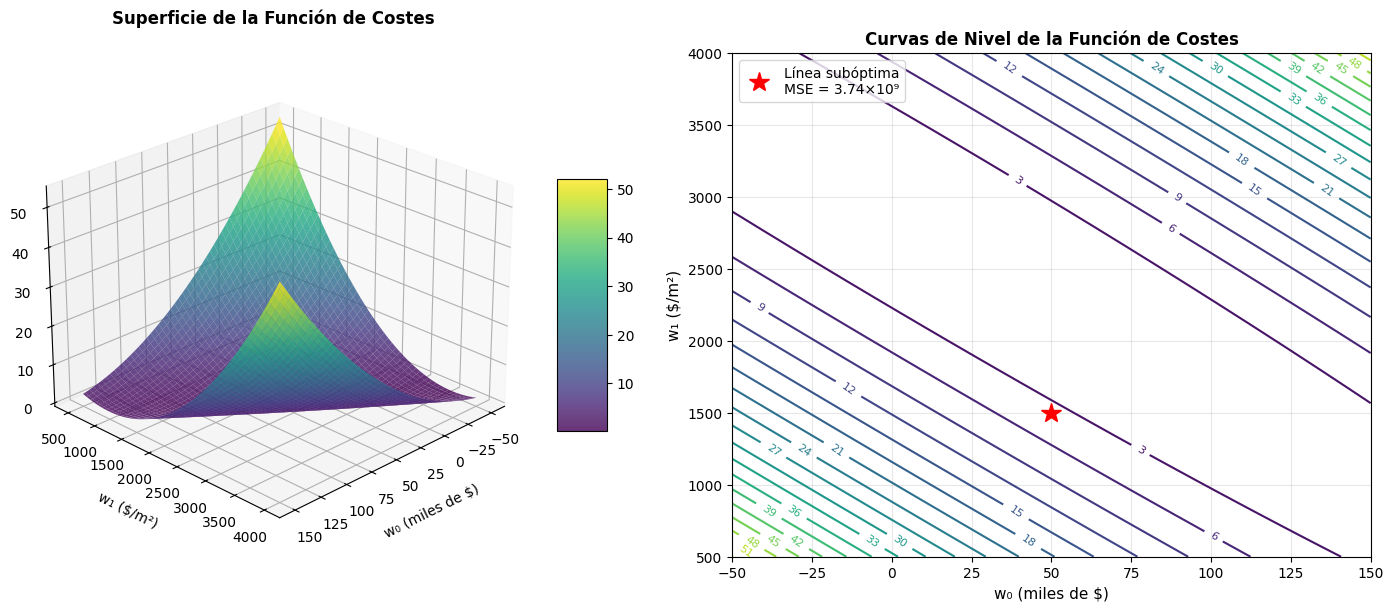

In [4]:
from mpl_toolkits.mplot3d import Axes3D

# Crear una rejilla de valores para w0 y w1
w0_vals = np.linspace(-50000, 150000, 100)
w1_vals = np.linspace(500, 4000, 100)
W0, W1 = np.meshgrid(w0_vals, w1_vals)

# Calcular el MSE para cada combinación de w0 y w1
J = np.zeros_like(W0)
for i in range(len(w0_vals)):
    for j in range(len(w1_vals)):
        J[j, i] = calcular_mse(W0[j, i], W1[j, i], area, precio)

# Crear el gráfico 3D
fig = plt.figure(figsize=(14, 6))

# Subplot 1: Vista 3D de la superficie
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(W0/1000, W1, J/1e9, cmap='viridis', alpha=0.8,
                        edgecolor='none', antialiased=True)
ax1.set_xlabel('\nw₀ (miles de $)', fontsize=10)
ax1.set_ylabel('\nw₁ ($/m²)', fontsize=10)
ax1.set_zlabel('\nMSE (×10⁹)', fontsize=10)
ax1.set_title('Superficie de la Función de Costes\n', fontsize=12, fontweight='bold')
ax1.view_init(elev=25, azim=45)
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=5)

# Subplot 2: Vista de contorno (curvas de nivel)
ax2 = fig.add_subplot(122)
contour = ax2.contour(W0/1000, W1, J/1e9, levels=20, cmap='viridis')
ax2.clabel(contour, inline=True, fontsize=8)
ax2.set_xlabel('w₀ (miles de $)', fontsize=11)
ax2.set_ylabel('w₁ ($/m²)', fontsize=11)
ax2.set_title('Curvas de Nivel de la Función de Costes', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Marcar el punto de la línea subóptima
ax2.plot(w0_bad/1000, w1_bad, 'r*', markersize=15,
         label=f'Línea subóptima\nMSE = {mse_bad/1e9:.2f}×10⁹')
ax2.legend()

plt.tight_layout()
plt.show()

**¿Qué nos muestra este gráfico?**

* **Superficie en forma de cuenco:** La función de costes tiene un único mínimo global (el punto más bajo del valle).
* **Curvas de nivel:** Cada línea en el gráfico de contorno representa combinaciones de $w_0$ y $w_1$ que producen el mismo error.
* **El punto rojo:** Nuestra línea subóptima está lejos del mínimo, en una zona de error alto.
* **El objetivo:** Queremos llegar al fondo del cuenco, donde $J$ es mínimo.

### La transformación del problema

Nuestro problema de "encontrar la mejor línea" se ha transformado en un **problema de optimización** mucho más claro:

> **Encontrar los valores de $w_0$ y $w_1$ que nos sitúen en el punto más bajo (el mínimo) de este cuenco.**

En términos matemáticos:

$$\min_{w_0, w_1} J(w_0, w_1) = \min_{w_0, w_1} \frac{1}{m} \sum_{i=1}^{m} (y_i - (w_0 + w_1 x_i))^2$$

**¿Cómo llegamos hasta allí?** Ahí es donde entra el **Descenso del Gradiente**.

En lugar de calcular directamente el mínimo (como hace la solución cerrada), el Descenso del Gradiente nos permite "caminar" por esta superficie, dando pasos calculados que nos llevan gradualmente hacia el fondo del valle.

En la siguiente sección, desarrollaremos la intuición de cómo funciona este "caminar inteligente" por la superficie de error.

---

## **3. La Intuición del Descenso del Gradiente**

Ahora que sabemos que nuestro objetivo es minimizar la función de costes $J(w_0, w_1)$, necesitamos un método para llegar al fondo del "cuenco". El **Descenso del Gradiente** es ese método.

Antes de sumergirnos en las matemáticas, construyamos una intuición sólida de cómo funciona este algoritmo.

### La Analogía del Montañero perdido en la niebla

Imagina que estás en la ladera de una montaña y hay una densa niebla que hace que tu visibilidad sea muy escasa. No puedes ver dónde está el valle (el punto más bajo), pero tu objetivo es llegar hasta allí.

Tu estrategia para descender sería:

1. **Te detienes** y miras el terreno a tu alrededor, viendo a muy pocos metros de ti.
2. **Determinas la dirección** en la que el terreno desciende más pronunciadamente (la dirección de máxima pendiente hacia abajo).
3. **Das un paso deliberado** en esa dirección. No te deslizas, sino que avanzas de forma controlada.
4. **Te vuelves a detener** en tu nueva posición y repites el proceso.
5. **Continúas iterando** hasta que el terreno bajo tus pies sea plano. Ya no puedes bajar más. En ese punto has llegado al valle.

**Esto es exactamente lo que hace el Descenso del Gradiente:**

| Montañero con niebla | Descenso del Gradiente |
|:----------------|:-----------------------|
| Posición en la montaña | Valores actuales de $w_0$ y $w_1$ |
| Altura sobre el nivel del mar | Valor de la función de costes $J(w_0, w_1)$ |
| Ver la pendiente local del terreno | Calcular el **gradiente** de $J$ |
| Dirección de máxima pendiente hacia abajo | Dirección opuesta al gradiente |
| Longitud del paso | **Tasa de aprendizaje** ($\alpha$) |
| Terreno plano (valle) | Mínimo de $J$ (gradiente ≈ 0) |
| Caminar paso a paso | **Iteraciones** del algoritmo |

**Lo crucial de esta analogía:** El montañero no se desliza sin control. Se **detiene en cada paso**, evalúa la pendiente local, y **decide conscientemente** hacia dónde moverse. Es un proceso iterativo **discreto y controlado**, no continuo. El Descenso del Gradiente hace exactamente esto, pero en el mundo de las matemáticas.

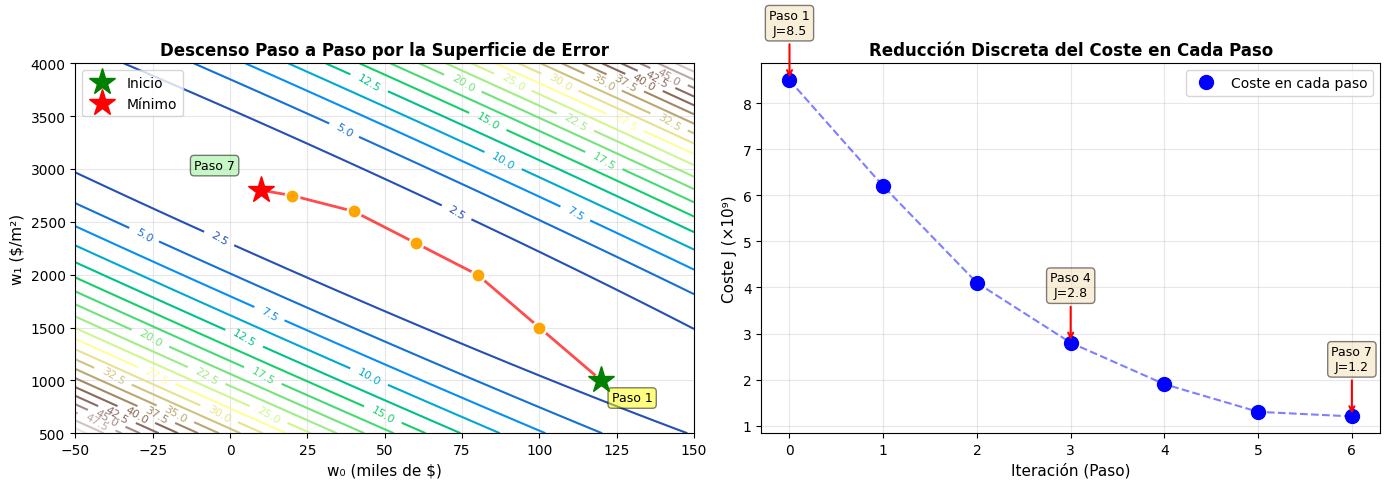

Proceso del montañero en la niebla (Gradient Descent):
  1. Detente en tu posición actual
  2. Mira el terreno → calcula el gradiente
  3. Da UN paso controlado hacia abajo
  4. Vuelve al paso 1 y repite

→ Es un proceso DISCRETO, no continuo
→ Cada paso es deliberado y calculado


In [5]:
# Visualización de la analogía del montañero (proceso paso a paso)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Ilustración conceptual con curvas de nivel
ax1 = axes[0]
w0_range = np.linspace(-50000, 150000, 100)
w1_range = np.linspace(500, 4000, 100)
W0_grid, W1_grid = np.meshgrid(w0_range, w1_range)
J_grid = np.zeros_like(W0_grid)
for i in range(len(w0_range)):
    for j in range(len(w1_range)):
        J_grid[j, i] = calcular_mse(W0_grid[j, i], W1_grid[j, i], area, precio)

contour = ax1.contour(W0_grid/1000, W1_grid, J_grid/1e9, levels=25, cmap='terrain')
ax1.clabel(contour, inline=True, fontsize=8)

# Simular un camino de descenso paso a paso (conceptual)
path_w0 = np.array([120, 100, 80, 60, 40, 20, 10])  # miles
path_w1 = np.array([1000, 1500, 2000, 2300, 2600, 2750, 2800])

# Dibujar cada paso con pausa visual
for i in range(len(path_w0)-1):
    ax1.plot([path_w0[i], path_w0[i+1]], [path_w1[i], path_w1[i+1]],
             'r-', linewidth=2, alpha=0.7)
    ax1.plot(path_w0[i], path_w1[i], 'o', color='orange', markersize=10,
             markeredgecolor='white', markeredgewidth=1.5)

ax1.plot(path_w0[0], path_w1[0], 'g*', markersize=20, label='Inicio', zorder=5)
ax1.plot(path_w0[-1], path_w1[-1], 'r*', markersize=20, label='Mínimo', zorder=5)

# Añadir anotaciones de "pasos"
ax1.annotate('Paso 1', xy=(path_w0[0], path_w1[0]), xytext=(path_w0[0]+10, path_w1[0]-200),
            fontsize=9, ha='center',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))
ax1.annotate('Paso 7', xy=(path_w0[-1], path_w1[-1]), xytext=(path_w0[-1]-15, path_w1[-1]+200),
            fontsize=9, ha='center',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

ax1.set_xlabel('w₀ (miles de $)', fontsize=11)
ax1.set_ylabel('w₁ ($/m²)', fontsize=11)
ax1.set_title('Descenso Paso a Paso por la Superficie de Error', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Subplot 2: Evolución del coste - énfasis en lo discreto
ax2 = axes[1]
iteraciones = np.arange(len(path_w0))
costes_simulados = np.array([8.5, 6.2, 4.1, 2.8, 1.9, 1.3, 1.2])  # Valores conceptuales

ax2.plot(iteraciones, costes_simulados, 'b--', linewidth=1.5, alpha=0.5)
ax2.plot(iteraciones, costes_simulados, 'bo', markersize=10, label='Coste en cada paso')

# Resaltar algunos pasos
for i in [0, 3, 6]:
    ax2.annotate(f'Paso {i+1}\nJ={costes_simulados[i]:.1f}',
                xy=(i, costes_simulados[i]),
                xytext=(i, costes_simulados[i] + 1),
                fontsize=9, ha='center',
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax2.set_xlabel('Iteración (Paso)', fontsize=11)
ax2.set_ylabel('Coste J (×10⁹)', fontsize=11)
ax2.set_title('Reducción Discreta del Coste en Cada Paso', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(iteraciones)
ax2.legend()

plt.tight_layout()
plt.show()

print("Proceso del montañero en la niebla (Gradient Descent):")
print("  1. Detente en tu posición actual")
print("  2. Mira el terreno → calcula el gradiente")
print("  3. Da UN paso controlado hacia abajo")
print("  4. Vuelve al paso 1 y repite")
print("\n→ Es un proceso DISCRETO, no continuo")
print("→ Cada paso es deliberado y calculado")

### ¿Qué es el Gradiente?

El **gradiente** es un concepto del cálculo multivariable, pero su interpretación geométrica es muy intuitiva:

> **El gradiente de una función en un punto es un vector que apunta en la dirección de máximo crecimiento de esa función.**

Para nuestra función de costes $J(w_0, w_1)$, el gradiente se denota como:

$$\nabla J(w_0, w_1) = \begin{bmatrix} \frac{\partial J}{\partial w_0} \\ \frac{\partial J}{\partial w_1} \end{bmatrix}$$

Donde:
* $\nabla$ (nabla) es el símbolo del gradiente
* $\frac{\partial J}{\partial w_0}$ es la **derivada parcial** de $J$ respecto a $w_0$ (cómo cambia $J$ cuando movemos $w_0$)
* $\frac{\partial J}{\partial w_1}$ es la **derivada parcial** de $J$ respecto a $w_1$ (cómo cambia $J$ cuando movemos $w_1$)

**Volviendo a la analogía del montañero:**
* Cuando miras el terreno a tu alrededor, estás "sintiendo" el gradiente.
* El gradiente te dice: "Si caminas en ESTA dirección, subirás más rápido".
* Por lo tanto, si caminas en la **dirección opuesta**, bajarás más rápido. Esto explica el signo negativo que introduciremos.

**En palabras simples:**
* Si estás en un punto de la superficie de la función de coste $J$, el gradiente te dice **"hacia dónde debes moverte para que el coste aumente más rápido"**.
* La **magnitud** del gradiente te dice **"qué tan empinada está la pendiente"** (si la pendiente es muy pronunciada, el gradiente es grande; si es casi plana, el gradiente es casi cero).

### ¿Por qué "Descender" Funciona?

Aquí está la clave del algoritmo:

**Si el gradiente apunta hacia arriba (dirección de máximo ascenso), entonces ir en la dirección OPUESTA nos lleva hacia abajo (máximo descenso).**

Por eso el algoritmo se llama **Descenso** del Gradiente: damos pasos en dirección opuesta al gradiente. Nuestro objetivo es ir hacia el mínimo coste.

Matemáticamente, esto se expresa como:

$$\text{Nueva posición} = \text{Posición actual} - \text{paso en dirección del gradiente}$$

O, más formalmente:

$$w_j^{\text{nuevo}} = w_j^{\text{actual}} - \alpha \cdot \frac{\partial J}{\partial w_j}$$

Donde:
* $w_j$ es uno de nuestros parámetros ($w_0$ o $w_1$)
* $\alpha$ (alfa) es la **tasa de aprendizaje** (learning rate): la longitud del paso que damos
* $\frac{\partial J}{\partial w_j}$ es la derivada parcial (la componente del gradiente)
* El signo **menos** ($-$) nos hace ir en dirección opuesta al gradiente (descender)

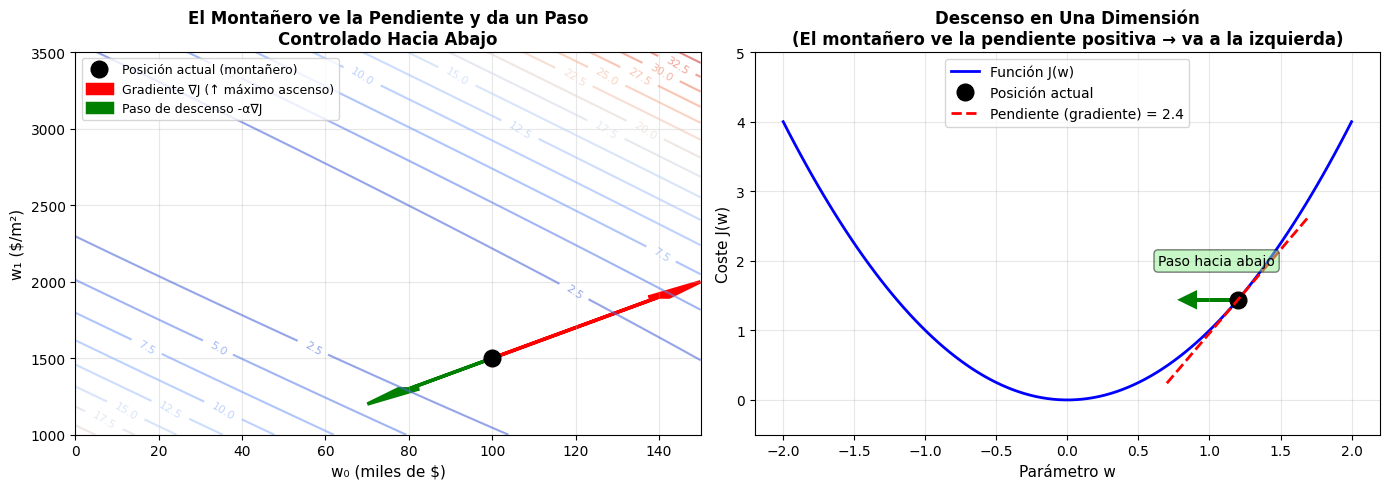

El montañero en acción:
  → El gradiente (rojo) apunta 'cuesta arriba' (dirección de máximo ascenso)
  → El montañero mira esta dirección y decide ir en dirección OPUESTA
  → Da un paso controlado (verde) hacia abajo
  → Se detiene, vuelve a mirar el terreno, y repite el proceso


In [6]:
# Visualización: Gradiente como vector en un punto
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Gradiente apuntando hacia arriba, descenso hacia abajo
ax1 = axes[0]
w0_fine = np.linspace(0, 150000, 80)
w1_fine = np.linspace(1000, 3500, 80)
W0_fine, W1_fine = np.meshgrid(w0_fine, w1_fine)
J_fine = np.zeros_like(W0_fine)
for i in range(len(w0_fine)):
    for j in range(len(w1_fine)):
        J_fine[j, i] = calcular_mse(W0_fine[j, i], W1_fine[j, i], area, precio)

contour1 = ax1.contour(W0_fine/1000, W1_fine, J_fine/1e9, levels=15, cmap='coolwarm', alpha=0.6)
ax1.clabel(contour1, inline=True, fontsize=8)

# Punto de ejemplo lejos del mínimo
punto_w0, punto_w1 = 100000, 1500
ax1.plot(punto_w0/1000, punto_w1, 'ko', markersize=12, label='Posición actual (montañero)')

# Simular dirección del gradiente (hacia arriba) y descenso (hacia abajo)
gradiente_w0, gradiente_w1 = 40, 400  # Valores ilustrativos
ax1.arrow(punto_w0/1000, punto_w1, gradiente_w0, gradiente_w1,
          head_width=5, head_length=100, fc='red', ec='red', linewidth=2.5,
          label='Gradiente ∇J (↑ máximo ascenso)')
ax1.arrow(punto_w0/1000, punto_w1, -gradiente_w0*0.5, -gradiente_w1*0.5,
          head_width=5, head_length=100, fc='green', ec='green', linewidth=2.5,
          label='Paso de descenso -α∇J')

ax1.set_xlabel('w₀ (miles de $)', fontsize=11)
ax1.set_ylabel('w₁ ($/m²)', fontsize=11)
ax1.set_title('El Montañero ve la Pendiente y da un Paso\nControlado Hacia Abajo',
              fontsize=12, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

# Subplot 2: Concepto de la pendiente en 1D
ax2 = axes[1]
x_demo = np.linspace(-2, 2, 100)
y_demo = x_demo**2  # Parábola simple

ax2.plot(x_demo, y_demo, 'b-', linewidth=2, label='Función J(w)')

# Punto en la pendiente positiva
punto_x = 1.2
punto_y = punto_x**2
pendiente = 2 * punto_x  # Derivada de x²

ax2.plot(punto_x, punto_y, 'ko', markersize=12, label='Posición actual')
# Línea tangente (representa el gradiente)
tangente_x = np.linspace(punto_x - 0.5, punto_x + 0.5, 50)
tangente_y = punto_y + pendiente * (tangente_x - punto_x)
ax2.plot(tangente_x, tangente_y, 'r--', linewidth=2, label=f'Pendiente (gradiente) = {pendiente:.1f}')

# Flecha de descenso
ax2.arrow(punto_x, punto_y, -0.3, 0, head_width=0.2, head_length=0.1,
          fc='green', ec='green', linewidth=2.5)
ax2.text(punto_x - 0.15, punto_y + 0.5, 'Paso hacia abajo', fontsize=10, ha='center',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

ax2.set_xlabel('Parámetro w', fontsize=11)
ax2.set_ylabel('Coste J(w)', fontsize=11)
ax2.set_title('Descenso en Una Dimensión\n(El montañero ve la pendiente positiva → va a la izquierda)',
              fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-0.5, 5)

plt.tight_layout()
plt.show()

print("El montañero en acción:")
print("  → El gradiente (rojo) apunta 'cuesta arriba' (dirección de máximo ascenso)")
print("  → El montañero mira esta dirección y decide ir en dirección OPUESTA")
print("  → Da un paso controlado (verde) hacia abajo")
print("  → Se detiene, vuelve a mirar el terreno, y repite el proceso")

### La Tasa de Aprendizaje: El Tamaño del Paso

La **tasa de aprendizaje** ($\alpha$) es un hiperparámetro crucial que controla qué tan grandes son los pasos que damos en cada iteración.

**Analogía:** Si el gradiente te dice "baja hacia la izquierda", la tasa de aprendizaje decide si das un paso pequeño (10 cm), mediano (1 metro) o grande (10 metros).

#### ¿Qué pasa con diferentes valores de $\alpha$?

| Tasa de aprendizaje | Comportamiento | Consecuencia |
|:--------------------|:---------------|:-------------|
| **Demasiado pequeña** ($\alpha \ll 1$) | Pasos muy pequeños | ↓ Convergencia extremadamente lenta. Puede necesitar millones de iteraciones. |
| **Óptima** | Pasos ni muy grandes ni muy pequeños | ↑↑ Convergencia rápida y estable hacia el mínimo. |
| **Demasiado grande** ($\alpha \gg 1$) | Pasos muy grandes | ↓ Oscilación alrededor del mínimo o divergencia (el error aumenta). |

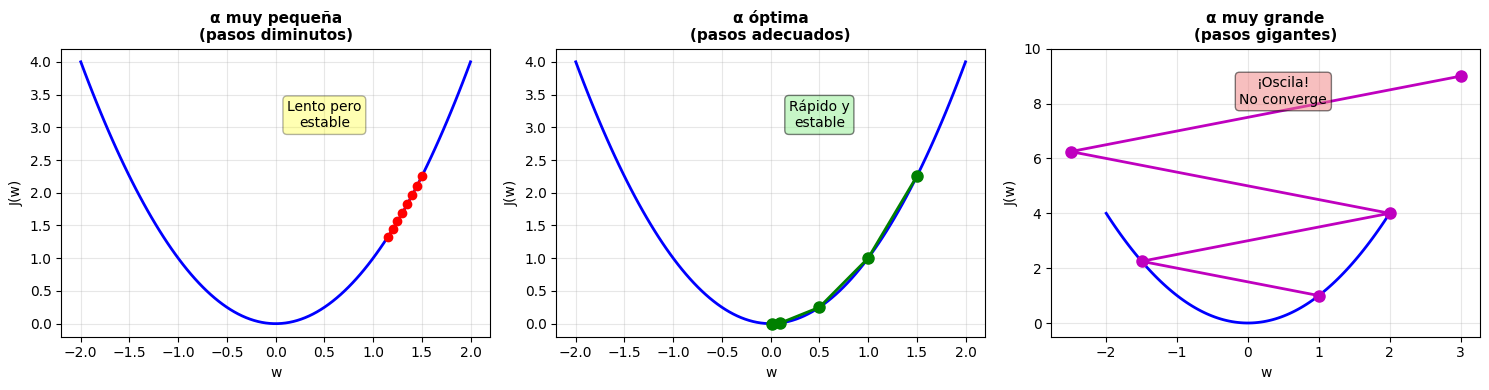

Observaciones clave:
  → Izquierda: α pequeña → muchos pasos para llegar al mínimo
  → Centro: α óptima → convergencia rápida y estable
  → Derecha: α grande → el algoritmo 'rebota' y nunca converge


In [7]:
# Visualización conceptual del efecto de alpha (lo implementaremos en detalle más adelante)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Función simple para demostrar
x_range = np.linspace(-2, 2, 100)
y_func = x_range**2

# Alpha muy pequeña
ax1 = axes[0]
ax1.plot(x_range, y_func, 'b-', linewidth=2)
trayectoria_pequeña = [1.5, 1.45, 1.40, 1.35, 1.30, 1.25, 1.20, 1.15]
y_pequeña = [x**2 for x in trayectoria_pequeña]
ax1.plot(trayectoria_pequeña, y_pequeña, 'ro-', markersize=6, linewidth=1.5)
ax1.set_title('α muy pequeña\n(pasos diminutos)', fontsize=11, fontweight='bold')
ax1.set_xlabel('w', fontsize=10)
ax1.set_ylabel('J(w)', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.text(0.5, 3, 'Lento pero\nestable', fontsize=10, ha='center',
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

# Alpha óptima
ax2 = axes[1]
ax2.plot(x_range, y_func, 'b-', linewidth=2)
trayectoria_optima = [1.5, 1.0, 0.5, 0.1, 0.01]
y_optima = [x**2 for x in trayectoria_optima]
ax2.plot(trayectoria_optima, y_optima, 'go-', markersize=8, linewidth=2)
ax2.set_title('α óptima\n(pasos adecuados)', fontsize=11, fontweight='bold')
ax2.set_xlabel('w', fontsize=10)
ax2.set_ylabel('J(w)', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.text(0.5, 3, 'Rápido y\nestable', fontsize=10, ha='center',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

# Alpha muy grande
ax3 = axes[2]
ax3.plot(x_range, y_func, 'b-', linewidth=2)
trayectoria_grande = [1.0, -1.5, 2.0, -2.5, 3.0]
y_grande = [x**2 for x in trayectoria_grande]
ax3.plot(trayectoria_grande, y_grande, 'mo-', markersize=8, linewidth=2)
ax3.set_title('α muy grande\n(pasos gigantes)', fontsize=11, fontweight='bold')
ax3.set_xlabel('w', fontsize=10)
ax3.set_ylabel('J(w)', fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_ylim(-0.5, 10)
ax3.text(0.5, 8, '¡Oscila!\nNo converge', fontsize=10, ha='center',
         bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))

plt.tight_layout()
plt.show()

print("Observaciones clave:")
print("  → Izquierda: α pequeña → muchos pasos para llegar al mínimo")
print("  → Centro: α óptima → convergencia rápida y estable")
print("  → Derecha: α grande → el algoritmo 'rebota' y nunca converge")

### El Algoritmo en Pseudocódigo

Ahora que entendemos la intuición, veamos el algoritmo completo en pseudocódigo:
```
1. Inicializar parámetros w₀ y w₁ (usualmente en 0 o valores aleatorios pequeños)
2. Repetir hasta convergencia:
   a. Calcular el gradiente de J respecto a w₀ y w₁
   b. Actualizar w₀ := w₀ - α × (∂J/∂w₀)
   c. Actualizar w₁ := w₁ - α × (∂J/∂w₁)
   d. (Opcional) Calcular y guardar el coste J actual
3. Devolver w₀ y w₁ finales
```

**Criterios de convergencia típicos:**
* Número fijo de iteraciones (ej. 1000 iteraciones)
* Cuando el cambio en el coste es muy pequeño (ej. $|J^{(t)} - J^{(t-1)}| < 0.0001$)
* Cuando el gradiente es casi cero (estamos en un punto plano)

### Resumen de la Intuición

Antes de pasar a las matemáticas y el código, recapitulemos lo esencial:

1. **El objetivo:** Minimizar la función de costes $J(w_0, w_1)$.

2. **La estrategia:** Dar pasos iterativos en la dirección que más reduce el coste.

3. **La herramienta:** El gradiente nos dice la dirección de máximo ascenso, así que vamos en dirección opuesta.

4. **El control:** La tasa de aprendizaje $\alpha$ controla el tamaño de cada paso.

5. **El resultado:** Después de suficientes iteraciones, llegamos al mínimo (o muy cerca de él).

En la siguiente sección, derivaremos las fórmulas matemáticas para calcular el gradiente de nuestra función de costes MSE y veremos cómo implementar el algoritmo completo en Python.

---

## **4. Las Piezas Clave del Algoritmo**

Ahora que entendemos la intuición, necesitamos las fórmulas matemáticas para implementar el algoritmo.

### Recordatorio: Lo que queremos minimizar

Nuestra función de costes es el Error Cuadrático Medio (MSE):

$$J(w_0, w_1) = \frac{1}{m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2 = \frac{1}{m} \sum_{i=1}^{m} (y_i - (w_0 + w_1 x_i))^2$$

> **Nota técnica sobre el factor 2:** En muchos libros  verás esta fórmula con un $\frac{1}{2m}$ en lugar de $\frac{1}{m}$. (Ej. $J = \frac{1}{2m} \sum...$). Este $\frac{1}{2}$ se añade por pura conveniencia matemática: al derivar $(y - \hat{y})^2$ obtenemos $2(y - \hat{y})$, y el factor $\frac{1}{2}$ cancela ese 2, simplificando las ecuaciones del gradiente. Multiplicar el gradiente por una constante no cambia la dirección del descenso, solo la magnitud. Por simplicidad y claridad, usamos las fórmulas sin el 2, que es la práctica estándar en la mayoría de implementaciones.

### Los componentes esenciales

El Descenso del Gradiente es simple, pero su eficacia reside en la correcta aplicación de dos componentes esenciales:
- A. El **Gradiente** (la dirección de la pendiente) y
- B. La **Tasa de Aprendizaje** (el tamaño del paso)

### A. El Gradiente: La Dirección de Máximo Descenso

Necesitamos calcular la pendiente de la función de costes $J(w_0, w_1)$ en nuestra posición actual. Esto se logra calculando las **derivadas parciales** de $J$ con respecto a cada parámetro ($w_0$ y $w_1$).

El resultado de estas derivadas nos dice cuánto cambiaría el coste $J$ si modificáramos ligeramente un parámetro, manteniendo el otro fijo.

#### El Gradiente

El gradiente es un vector que apunta en la dirección de máximo crecimiento. Como estamos buscando el mínimo coste, nos moveremos en la dirección opuesta (introduciremos un signo menos en la actualización).

Derivando $J(w_0, w_1) = \frac{1}{2m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2$ con respecto a cada parámetro, obtenemos inicialmente un término negativo: $-\frac{1}{m}\sum(y_i - \hat{y}_i)$.

Para simplificar la notación y eliminar el signo negativo, **reordenamos algebraicamente** la resta:
$$-(y_i - \hat{y}_i) = (\hat{y}_i - y_i)$$

Esto nos da las siguientes fórmulas del gradiente:

1.  **Gradiente con respecto a $w_0$ (el sesgo):**
    $$\frac{\partial J}{\partial w_0} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)$$
    *Esta derivada es simplemente la media de todos los errores de predicción.*

2.  **Gradiente con respecto a $w_1$ (el peso/pendiente):**
    $$\frac{\partial J}{\partial w_1} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i) \cdot x_i$$
    *Esta derivada incluye la característica $x_i$, lo que da más peso a los puntos con valores grandes de $x$ en el ajuste de la pendiente.*


**Interpretación intuitiva:**
* Ambas fórmulas calculan un **promedio de errores** (tienen $\frac{1}{m}$)
* Si sobre-estimamos $(\hat{y}_i > y_i)$, el gradiente es positivo → debemos reducir los parámetros
* Si sub-estimamos $(\hat{y}_i < y_i)$, el gradiente es negativo → debemos aumentar los parámetros
* La única diferencia entre ambas fórmulas: el gradiente de $w_1$ está multiplicado por $x_i$ (el valor de entrada)

---

### B. La Tasa de Aprendizaje ($\alpha$): El Tamaño del Paso

La **tasa de aprendizaje** ($\alpha$) es un **hiperparámetro** fundamental que controla la magnitud de los pasos que damos en la dirección del gradiente.

#### La Regla de Actualización

Con la dirección del gradiente y el tamaño del paso $\alpha$, definimos la regla de actualización. Esta se aplica repetidamente durante un número predefinido de iteraciones (**épocas**):

Repetir (Iteraciones/Épocas) {

$$w_0 := w_0 - \alpha \frac{\partial J}{\partial w_0}$$
$$w_1 := w_1 - \alpha \frac{\partial J}{\partial w_1}$$

}

#### El Impacto Crítico de $\alpha$

Elegir el valor de $\alpha$ correcto es un acto de equilibrio:

| Si $\alpha$ es... | Consecuencia... |
| :--- | :--- |
| **Demasiado Pequeña** | Convergencia **extremadamente lenta**. Se necesitan miles de épocas. |
| **Correcta** | Convergencia eficiente, acercándose al mínimo en un número razonable de pasos. |
| **Demasiado Grande** | **Divergencia** u **oscilación**. El modelo salta de un lado a otro, o se aleja del mínimo, haciendo que el coste $J$ aumente. |

El impacto de $\alpha$ es particularmente sensible cuando las características de entrada tienen rangos de valores muy diferentes. De hecho, esta sensibilidad extrema es la razón principal por la que la **normalización de características** es un paso obligatorio en la práctica, ya que permite usar un $\alpha$ más grande sin riesgo de divergencia.

---

### Nota sobre el Cálculo Simultáneo

Es vital entender que, dentro de cada paso (cada época), las actualizaciones de $w_0$ y $w_1$ deben realizarse **simultáneamente**.

Esto significa que primero se deben calcular *ambas* derivadas (gradientes) utilizando los valores de $w_0$ y $w_1$ de la *iteración anterior*. Una vez que se tienen los dos gradientes, se actualizan ambos parámetros a sus nuevos valores. Si se actualizara $w_0$ y luego se usara el *nuevo* $w_0$ para calcular la derivada de $w_1$, se introduciría un sesgo en el algoritmo que podría llevar a resultados incorrectos.

### La regla de actualización

En cada iteración, actualizamos los parámetros usando esta regla simple:

$$w_0 := w_0 - \alpha \cdot \frac{\partial J}{\partial w_0}$$

$$w_1 := w_1 - \alpha \cdot \frac{\partial J}{\partial w_1}$$

O, sustituyendo las fórmulas del gradiente:

$$\boxed{w_0 := w_0 - \alpha \cdot \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)}$$

$$\boxed{w_1 := w_1 - \alpha \cdot \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i) \cdot x_i}$$

Donde:
* $:=$ significa "actualiza el valor de..." (equivalente a `w0 = w0 - ...` en Python)
* $\alpha$ es la **tasa de aprendizaje** (learning rate), típicamente entre 0.001 y 0.1
* El signo **menos** nos hace descender (ir en dirección opuesta al gradiente)

In [8]:
# Implementación directa de las fórmulas
def calcular_gradientes(w0, w1, x, y):
    """Calcula los gradientes según las fórmulas derivadas"""
    m = len(y)
    y_pred = w0 + w1 * x
    error = y_pred - y

    dw0 = (1/m) * np.sum(error)
    dw1 = (1/m) * np.sum(error * x)

    return dw0, dw1

# Ejemplo rápido
w0_test, w1_test = 50000, 1500
dw0, dw1 = calcular_gradientes(w0_test, w1_test, area, precio)

print(f"Con w₀ = ${w0_test:,} y w₁ = ${w1_test:,}/m²:")
print(f"  Gradiente ∂J/∂w₀ = {dw0:,.2f}")
print(f"  Gradiente ∂J/∂w₁ = {dw1:,.2f}")
print(f"\nComo ambos gradientes son positivos, debemos REDUCIR")
print(f"ambos parámetros para disminuir el error.")

Con w₀ = $50,000 y w₁ = $1,500/m²:
  Gradiente ∂J/∂w₀ = -55,800.00
  Gradiente ∂J/∂w₁ = -4,424,200.00

Como ambos gradientes son positivos, debemos REDUCIR
ambos parámetros para disminuir el error.





### Los pasos necesarios

Esto es todo lo que necesitas saber para implementar Gradient Descent:

**Inicialización:**
```
w₀ = 0, w₁ = 0
Elegir α (ej. 0.01)
Elegir número de iteraciones (ej. 1000)
```

**Bucle de entrenamiento (repetir para cada iteración):**
```
1. Calcular predicciones: ŷᵢ = w₀ + w₁xᵢ
2. Calcular gradientes usando las fórmulas de arriba
3. Actualizar: w₀ := w₀ - α × ∂J/∂w₀
4. Actualizar: w₁ := w₁ - α × ∂J/∂w₁
```

**Eso es todo.** No hay más fórmulas secretas ni matemáticas ocultas.

### ¿Qué controla la tasa de aprendizaje α?

| Valor de α | Comportamiento | Cuándo usarlo |
|:-----------|:---------------|:--------------|
| Muy pequeña (0.001) | Pasos diminutos, convergencia lenta | Cuando el algoritmo oscila o diverge |
| Moderada (0.01) | Balance entre velocidad y estabilidad | ↑↑ Punto de partida recomendado |
| Grande (0.1+) | Pasos grandes, riesgo de oscilar | Solo si converge muy lento |

**Regla práctica:** Empieza con $\alpha = 0.01$. Si el coste oscila o aumenta, reduce $\alpha$. Si converge muy lento, aumenta $\alpha$ ligeramente.

En la siguiente sección, traduciremos estas fórmulas directamente a Python y veremos el algoritmo en acción.

---

## **5. Implementación del Algoritmo**

Implementemos el algoritmo de Gradient Descent paso a paso. Para que funcione correctamente con una tasa de aprendizaje razonable (α = 0.01), **normalizaremos los datos primero**.

### Normalización de los Datos

Sin normalización, los gradientes serían enormes y necesitaríamos α ≈ 0.0000001. Con normalización (StandardScaler), podemos usar α = 0.01 y converger mucho más rápido.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Dataset
area = np.array([50, 55, 60, 64, 70, 78, 80, 89, 90, 100])
precio = np.array([140000, 155000, 190000, 200000, 225000,
                  212000, 240000, 230000, 270000, 300000])

# Normalizar área (Z-score)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(area.reshape(-1, 1)).flatten()

# Guardar parámetros para desnormalizar después
mu, sigma = scaler.mean_[0], scaler.scale_[0]

# Matriz de diseño: [1, x_escalado]
X_b = np.c_[np.ones(len(X_scaled)), X_scaled]

print(f"Datos normalizados: μ = {mu:.2f}, σ = {sigma:.2f}")
print(f"Primeros valores escalados: {X_scaled[:3]}")

Datos normalizados: μ = 73.60, σ = 15.67
Primeros valores escalados: [-1.50578324 -1.18676137 -0.86773949]


### El Algoritmo Completo

In [10]:
def gradient_descent(X_b, y, alpha=0.01, num_iter=1000, tol=1e-6):
    """Gradient Descent con early stopping"""
    m, w = len(y), np.zeros(2)
    historial = []
    prev_cost = np.inf

    for i in range(num_iter):
        # Predicciones y error
        y_pred = X_b @ w
        error = y_pred - y

        # Gradientes
        gradients = (1/m) * X_b.T @ error

        # Actualizar
        w = w - alpha * gradients

        # Coste
        cost = (1/(2*m)) * np.sum(error**2)
        historial.append(cost)

        # Early stopping
        if prev_cost - cost < tol:
            print(f"Convergencia en iteración {i+1}")
            break
        prev_cost = cost

        if (i + 1) % 200 == 0:
            print(f"Iter {i+1}: J = {cost:.6f}")

    return w, historial

# Entrenar
print("\nEntrenamiento:")
w_scaled, historial = gradient_descent(X_b, precio, alpha=0.01, num_iter=1000)


Entrenamiento:
Iter 200: J = 551773641.020415
Iter 400: J = 114194915.137392
Iter 600: J = 106340134.906403
Iter 800: J = 106199137.255403
Iter 1000: J = 106196606.269557


### Desnormalización: Parámetros en Escala Original

Los parámetros `w_scaled` son válidos solo para datos normalizados. Debemos convertirlos al espacio original:

In [11]:
# Desnormalizar
w1_original = w_scaled[1] / sigma
w0_original = w_scaled[0] - w1_original * mu

print(f"\nParámetros finales:")
print(f"  w₀ = ${w0_original:,.2f}")
print(f"  w₁ = ${w1_original:,.2f}/m²")
print(f"\nModelo: Precio = ${w0_original:,.2f} + ${w1_original:,.2f} × Área")


Parámetros finales:
  w₀ = $10,722.38
  w₁ = $2,791.69/m²

Modelo: Precio = $10,722.38 + $2,791.69 × Área


### Visualización Rápida

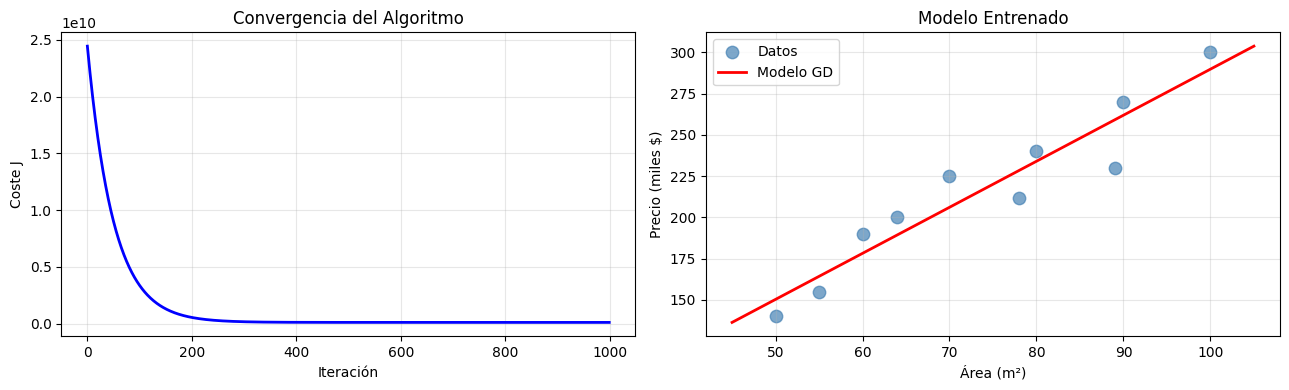


Predicción: Casa de 75m² → $220,099


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Convergencia
axes[0].plot(historial, 'b-', linewidth=2)
axes[0].set_xlabel('Iteración')
axes[0].set_ylabel('Coste J')
axes[0].set_title('Convergencia del Algoritmo')
axes[0].grid(alpha=0.3)

# Modelo final
axes[1].scatter(area, precio/1000, s=80, alpha=0.7, color='steelblue', label='Datos')
area_line = np.linspace(45, 105, 100)
precio_line = w0_original + w1_original * area_line
axes[1].plot(area_line, precio_line/1000, 'r-', linewidth=2, label='Modelo GD')
axes[1].set_xlabel('Área (m²)')
axes[1].set_ylabel('Precio (miles $)')
axes[1].set_title('Modelo Entrenado')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Ejemplo de predicción
area_nueva = 75
precio_pred = w0_original + w1_original * area_nueva
print(f"\nPredicción: Casa de {area_nueva}m² → ${precio_pred:,.0f}")

---

## **6. Conclusión y Vista Previa de la Parte 2**

### Lo que hemos aprendido

En este artículo, hemos construido una comprensión completa del Descenso del Gradiente:

* **La intuición:** El montañero en la niebla que desciende paso a paso mirando localmente la pendiente
* **Las matemáticas esenciales:** Gradientes y la regla de actualización $w := w - \alpha \nabla J$
* **La implementación:** Un algoritmo funcional en ~20 líneas de código
* **La normalización:** Esencial para convergencia rápida y estable

**Resultados obtenidos:**
* Convergencia en ~500-600 iteraciones
* Modelo funcional: `Precio ≈ $10,723 + $2,792 × Área`
* Tasa de aprendizaje razonable (α = 0.01) gracias al escalado

### ¿Qué sigue en la Parte 2?

Has dominado los fundamentos. En la **Parte 2**, profundizaremos en aspectos críticos para aplicaciones del mundo real:

| Tema | Lo que aprenderás | Por qué importa |
|:-----|:------------------|:----------------|
| **Hiperparámetros** | Optimizar α y criterios de convergencia | Convergencia 10x más rápida |
| **Escalado Profundo** | StandardScaler vs otros métodos | Entender el "por qué" del escalado |
| **Variantes del Algoritmo** | Batch vs SGD vs Mini-Batch | Escalar a millones de datos |
| **Comparación con sklearn** | SGDRegressor y LinearRegression | Validar tu implementación |
| **Regresión Múltiple** | Múltiples características (2D → 3D) | Problemas reales del mundo |

**El viaje del montañero continúa.** Estás listo para técnicas avanzadas que hacen del Gradient Descent la base de todo el Deep Learning moderno.

#### → [Ir a Gradient Descent Part 2: Advanced Practices & Scaling](link_parte_2)

---

*Si este artículo te resultó útil, dale un ↑ **upvote** en Kaggle y compártelo con otros aprendices de ML.*

---